In [5]:
# Import Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    silhouette_score
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

In [6]:
# Load the dataset
df = pd.read_csv("../data/Ecommerce.csv")

# Display first 5 rows
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [7]:
# Dataset Shape
print("Shape of dataset:", df.shape)

# Column Names
print("\nColumns:")
print(df.columns)

# Dataset Information
print("\nDataset Info:")
df.info()

Shape of dataset: (25000, 29)

Columns:
Index(['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type',
       'marketing_channel', 'product_id', 'product_category', 'unit_price',
       'quantity', 'discount_percent', 'discount_amount', 'revenue',
       'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased',
       'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes',
       'payment_method', 'visit_day', 'visit_month', 'visit_weekday',
       'visit_season', 'session_duration_bucket', 'revenue_normalized',
       'location'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  str    
 3   device_type          

In [8]:
# Missing Values
print("Missing Values:")
print(df.isnull().sum())


Missing Values:
customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64


In [9]:
# Summary Statistics
df.describe(include='all')

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
count,25000.000000,25000.000000,25000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,...,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.00000
unique,NaN,NaN,365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN
top,NaN,NaN,28-05-2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Very Short,NaN,NaN
freq,NaN,NaN,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6270,NaN,NaN
mean,5479.930600,12499.500000,NaN,0.705040,0.551280,2.514040,449.107000,3.495240,782.319010,2.489040,...,1.67488,5.52080,2.483160,15.714520,6.510520,2.980800,1.504400,NaN,0.051290,111.70692
std,2593.544596,7217.022701,NaN,0.639543,0.497373,1.704934,259.513787,2.285053,476.612168,1.114563,...,1.98673,12.33629,1.709501,8.796338,3.457925,1.992554,1.117475,NaN,0.129591,65.07079
min,1000.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,50.050000,1.000000,...,0.00000,0.00000,0.000000,1.000000,1.000000,0.000000,0.000000,NaN,0.000000,0.00000
25%,3234.000000,6249.750000,NaN,0.000000,0.000000,1.000000,225.000000,2.000000,395.222500,1.000000,...,1.00000,0.00000,1.000000,8.000000,3.000000,1.000000,1.000000,NaN,0.000000,55.00000
50%,5482.000000,12499.500000,NaN,1.000000,1.000000,2.000000,448.000000,4.000000,691.725000,2.000000,...,1.00000,0.00000,2.000000,16.000000,7.000000,3.000000,2.000000,NaN,0.000000,111.00000
75%,7715.000000,18749.250000,NaN,1.000000,1.000000,4.000000,675.000000,5.000000,1096.842500,3.000000,...,1.00000,0.00000,4.000000,23.000000,10.000000,5.000000,3.000000,NaN,0.000000,169.00000


In [10]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicates removed successfully!")
print("New Shape:", df.shape)

Duplicates removed successfully!
New Shape: (25000, 29)


In [11]:
# Check missing values
print(df.isnull().sum())

# Fill numerical columns with median
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical columns with mode
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully!")

customer_id                0
session_id                 0
visit_date                 0
device_type                0
user_type                  0
marketing_channel          0
product_id                 0
product_category           0
unit_price                 0
quantity                   0
discount_percent           0
discount_amount            0
revenue                    0
pages_viewed               0
time_on_site_sec           0
added_to_cart              0
purchased                  0
cart_abandoned             0
rating                     0
review_text                0
review_helpful_votes       0
payment_method             0
visit_day                  0
visit_month                0
visit_weekday              0
visit_season               0
session_duration_bucket    0
revenue_normalized         0
location                   0
dtype: int64
Missing values handled successfully!


In [12]:
# Encode categorical columns
label_encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("Categorical columns encoded successfully!")

Categorical columns encoded successfully!


In [13]:
# Display first 5 rows after preprocessing
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,334,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,0,0.000000,209
1,7964,1,296,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,0,0.000000,213
2,6890,2,361,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,1,0.000000,10
3,4949,3,348,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,2,0.305504,46
4,4896,4,289,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,3,0.000000,118


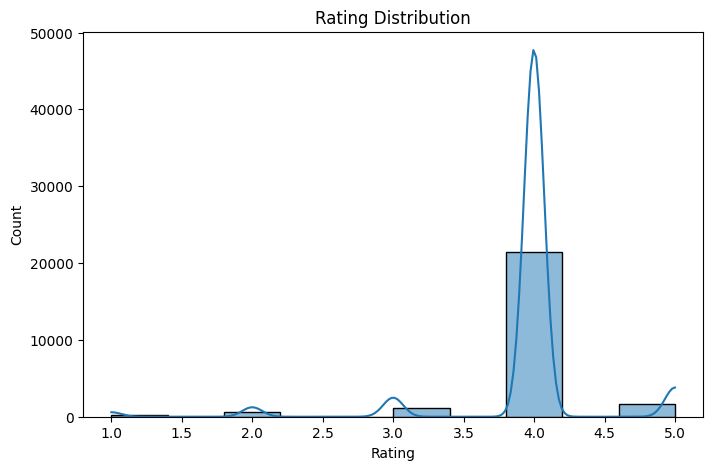

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["rating"], bins=10, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("../charts/rating_distribution.png")
plt.show()

In [15]:
df.columns

Index(['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type',
       'marketing_channel', 'product_id', 'product_category', 'unit_price',
       'quantity', 'discount_percent', 'discount_amount', 'revenue',
       'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased',
       'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes',
       'payment_method', 'visit_day', 'visit_month', 'visit_weekday',
       'visit_season', 'session_duration_bucket', 'revenue_normalized',
       'location'],
      dtype='str')

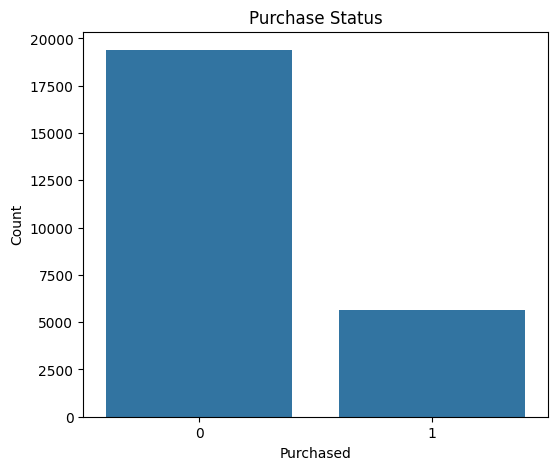

In [17]:
plt.figure(figsize=(6,5))
sns.countplot(x="purchased", data=df)

plt.title("Purchase Status")
plt.xlabel("Purchased")
plt.ylabel("Count")

plt.savefig("../charts/purchase_status.png")
plt.show()

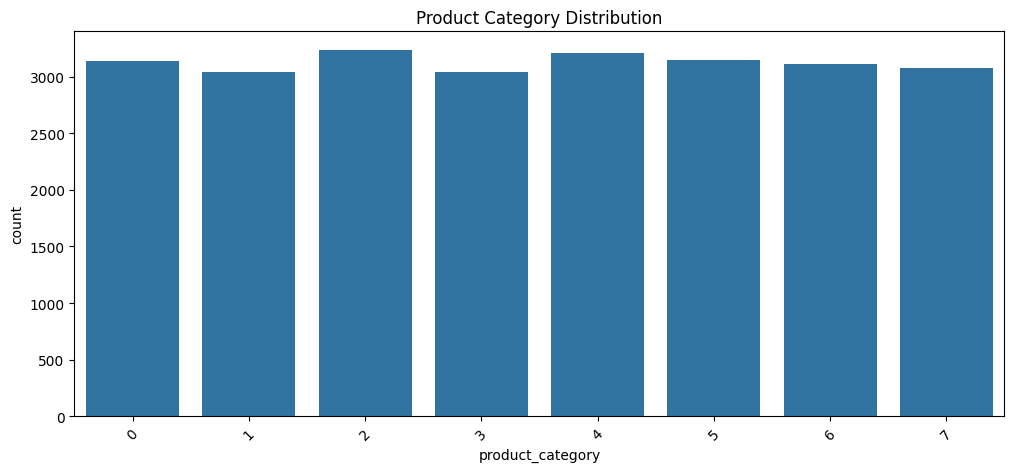

In [18]:
plt.figure(figsize=(12,5))
sns.countplot(x="product_category", data=df)

plt.xticks(rotation=45)
plt.title("Product Category Distribution")

plt.savefig("../charts/category_distribution.png")
plt.show()

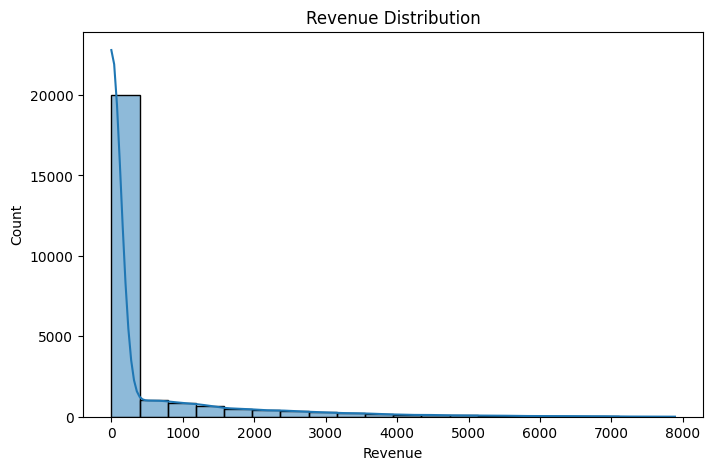

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["revenue"], bins=20, kde=True)

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")

plt.savefig("../charts/revenue_distribution.png")
plt.show()

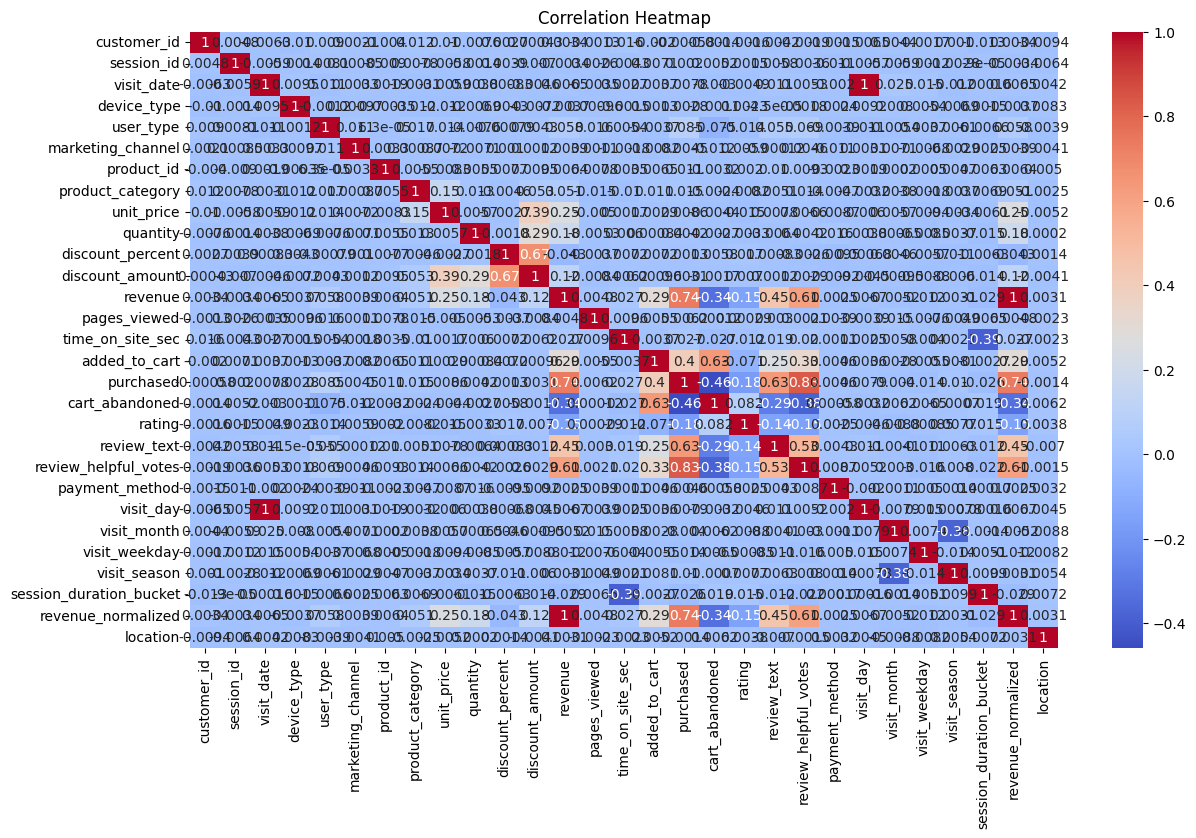

In [20]:
plt.figure(figsize=(14,8))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("../charts/correlation_heatmap.png")
plt.show()

In [21]:
# Features (X)
X = df[[
    "unit_price",
    "discount_percent",
    "revenue",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart"
]]

# Target (y)
y = df["rating"]

print(X.head())
print(y.head())

   unit_price  discount_percent  revenue  pages_viewed  time_on_site_sec  \
0      651.57                20     0.00            21               965   
1      945.27                15     0.00            21              1158   
2      400.44                 0     0.00            19               710   
3     1268.54                 5  2410.23            19              1674   
4      880.81                 0     0.00            13               427   

   added_to_cart  
0              1  
1              0  
2              1  
3              1  
4              1  
0    4
1    4
2    4
3    4
4    4
Name: rating, dtype: int64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (20000, 6)
Testing Data: (5000, 6)


In [23]:
from sklearn.linear_model import LinearRegression

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [24]:
# Predict ratings
y_pred = lr_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[3.6613131  3.99899836 3.95226744 3.97672171 3.95894992 3.89254684
 3.99157184 4.00049881 3.99840749 3.96421666]


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
----------------
MAE : 0.21751442023906378
MSE : 0.2951377827150591
RMSE: 0.543265849023348
R² Score: 0.026063627044116466


In [26]:
from sklearn.linear_model import Ridge

# Create Ridge model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train, y_train)

# Predict
ridge_pred = ridge_model.predict(X_test)

# Evaluate
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("------------------------")
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

Ridge Regression Results
------------------------
MAE : 0.21751338163451245
MSE : 0.2951378068207624
RMSE: 0.5432658712092656
R² Score: 0.026063547496791073


In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "MAE": [mae, ridge_mae],
    "RMSE": [rmse, ridge_rmse],
    "R2 Score": [r2, ridge_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.217514,0.543266,0.026064
1,Ridge Regression,0.217513,0.543266,0.026064


In [29]:
comparison.to_csv("../outputs/regression_results.csv", index=False)

print("Regression results saved successfully!")

Regression results saved successfully!


In [30]:
# Features
X = df[[
    "unit_price",
    "discount_percent",
    "revenue",
    "pages_viewed",
    "time_on_site_sec",
    "added_to_cart",
    "rating"
]]

# Target
y = df["purchased"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [32]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [33]:
y_pred = log_model.predict(X_test)

In [34]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [35]:
from sklearn.metrics import roc_auc_score

# Probability predictions
y_prob = log_model.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 1.0


In [36]:
classification_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc
    ]
})

classification_results

,Metric,Value
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1 Score,1.0
4,ROC-AUC,1.0


In [37]:
classification_results.to_csv("../outputs/classification_results.csv", index=False)

print("Classification results saved successfully!")

Classification results saved successfully!


In [38]:
from sklearn.preprocessing import StandardScaler

cluster_features = df[[
    "revenue",
    "time_on_site_sec",
    "pages_viewed",
    "discount_percent"
]]

scaler = StandardScaler()
cluster_scaled = scaler.fit_transform(cluster_features)

print("Data scaled successfully!")

Data scaled successfully!


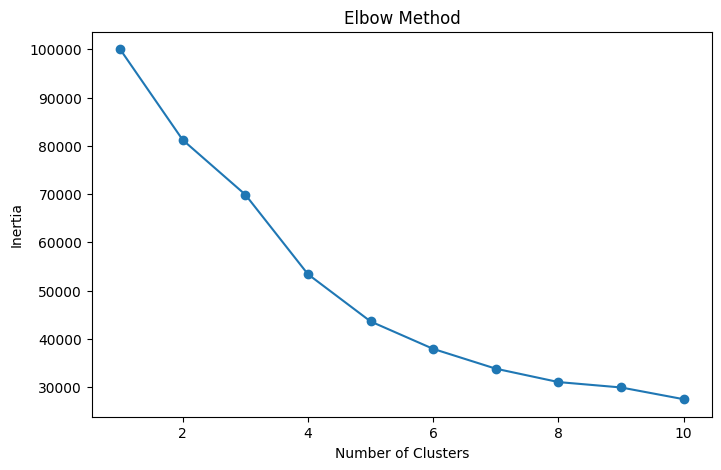

In [39]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.savefig("../charts/elbow_curve.png")
plt.show()

In [40]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(cluster_scaled)

df["Cluster"] = clusters

print(df[["Cluster"]].head())

   Cluster
0        1
1        1
2        1
3        1
4        0


In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(cluster_scaled, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.19835133828375373


In [42]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(ridge, param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Alpha:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Alpha: {'alpha': 1}
Best Score: 0.6069516542607741


In [43]:
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 0.01, 'solver': 'liblinear'}
Best Score: 1.0


In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 2

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(cluster_scaled)

    score = silhouette_score(cluster_scaled, labels)

    if score > best_score:
        best_score = score
        best_k = k

print("Best Number of Clusters:", best_k)
print("Best Silhouette Score:", best_score)

Best Number of Clusters: 7
Best Silhouette Score: 0.26362864072530906


In [45]:
df.to_csv("../outputs/clusters.csv", index=False)

print("Cluster results saved successfully!")

Cluster results saved successfully!


In [46]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Logistic Regression",
        "K-Means"
    ],
    "Evaluation": [
        f"R² = {r2:.3f}",
        f"R² = {ridge_r2:.3f}",
        f"Accuracy = {accuracy_score(y_test, y_pred):.3f}",
        f"Silhouette = {best_score:.3f}"
    ],
    "Business Use": [
        "Predict Product Ratings",
        "Improve Rating Prediction",
        "Predict Customer Purchase",
        "Customer Segmentation"
    ]
})

comparison

,Model,Evaluation,Business Use
0,Linear Regression,R² = 0.026,Predict Product Ratings
1,Ridge Regression,R² = 0.026,Improve Rating Prediction
2,Logistic Regression,Accuracy = 1.000,Predict Customer Purchase
3,K-Means,Silhouette = 0.264,Customer Segmentation


In [47]:
comparison.to_csv("../outputs/model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!
